# Response Scoring

## Goal
Automatically score the quality of model responses.
No human labeling — we use semantic similarity as a proxy.

## Approach
1. Define a question with a known correct answer
2. Get model response
3. Score by comparing response to correct answer semantically

## Key Question
Can we build an automated evaluation pipeline
that correlates with human judgment?

In [1]:
import requests
import pandas as pd
import matplotlib.pyplot as plt
from sentence_transformers import SentenceTransformer
from sklearn.metrics.pairwise import cosine_similarity
import numpy as np

## 1. Define Questions with Reference Answers

In [2]:
context = """
The Eiffel Tower was built between 1887 and 1889.
It is located in Paris, France, on the Champ de Mars.
The tower is 330 meters tall including its antenna.
It was designed by Gustave Eiffel and his engineering company.
The tower was originally intended to be a temporary structure
and was almost demolished in 1909.
It receives approximately 7 million visitors per year.
"""

# Questions with reference answers
qa_pairs = [
    {
        "question": "Where is the Eiffel Tower located?",
        "reference": "The Eiffel Tower is located in Paris, France, on the Champ de Mars."
    },
    {
        "question": "Who designed the Eiffel Tower?",
        "reference": "The Eiffel Tower was designed by Gustave Eiffel and his engineering company."
    },
    {
        "question": "How tall is the Eiffel Tower?",
        "reference": "The Eiffel Tower is 330 meters tall including its antenna."
    },
    {
        "question": "When was the Eiffel Tower built?",
        "reference": "The Eiffel Tower was built between 1887 and 1889."
    },
    {
        "question": "How many visitors does the Eiffel Tower receive per year?",
        "reference": "The Eiffel Tower receives approximately 7 million visitors per year."
    },
]

print(f"Total QA pairs: {len(qa_pairs)}")

Total QA pairs: 5


## 2. Get Model Responses and Score

In [7]:
embed_model = SentenceTransformer("all-MiniLM-L6-v2")

def query_model(question: str, context: str) -> str:
    prompt = f"""Context:
{context}

Question: {question}
Answer:"""
    
    response = requests.post(
      "http://127.0.0.1:11434/api/chat",
        json={
            "model": "gemma3:12b",
            "messages": [
                {"role": "user", "content": prompt}
            ],
            "stream": False
        },
        proxies={"http": None, "https": None}
    )
    return response.json()["message"]["content"]


def score_response(response: str, reference: str) -> float:
    """Score response quality by semantic similarity to refrence answer."""
    response_emb = embed_model.encode([response])
    reference_emb = embed_model.encode([reference])
    return float(cosine_similarity(response_emb, reference_emb)[0][0])


# Evaluate all QA pairs
print("Evaluating responses...")
results = []

for qa in qa_pairs:
    response = query_model(qa["question"], context)
    score = score_response(response, qa["reference"])
    results.append({
        "question": qa["question"],
        "reference": qa["reference"],
        "response": response,
        "score": score
    })
    print(f"\nQ: {qa["question"]}")
    print(f"Reference: {qa["reference"]}")
    print(f"Response: {response}")
    print(f"Score: {score:.4f}")

df = pd.DataFrame(results)
print(f"\nAverage Score: {df["score"].mean():.4f}")

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

Evaluating responses...

Q: Where is the Eiffel Tower located?
Reference: The Eiffel Tower is located in Paris, France, on the Champ de Mars.
Response: Paris, France, on the Champ de Mars.
Score: 0.6247

Q: Who designed the Eiffel Tower?
Reference: The Eiffel Tower was designed by Gustave Eiffel and his engineering company.
Response: Gustave Eiffel and his engineering company.
Score: 0.7965

Q: How tall is the Eiffel Tower?
Reference: The Eiffel Tower is 330 meters tall including its antenna.
Response: 330 meters
Score: 0.4941

Q: When was the Eiffel Tower built?
Reference: The Eiffel Tower was built between 1887 and 1889.
Response: Between 1887 and 1889.
Score: 0.4590

Q: How many visitors does the Eiffel Tower receive per year?
Reference: The Eiffel Tower receives approximately 7 million visitors per year.
Response: Approximately 7 million visitors.
Score: 0.6144

Average Score: 0.5977


## 3. Visualize Scores

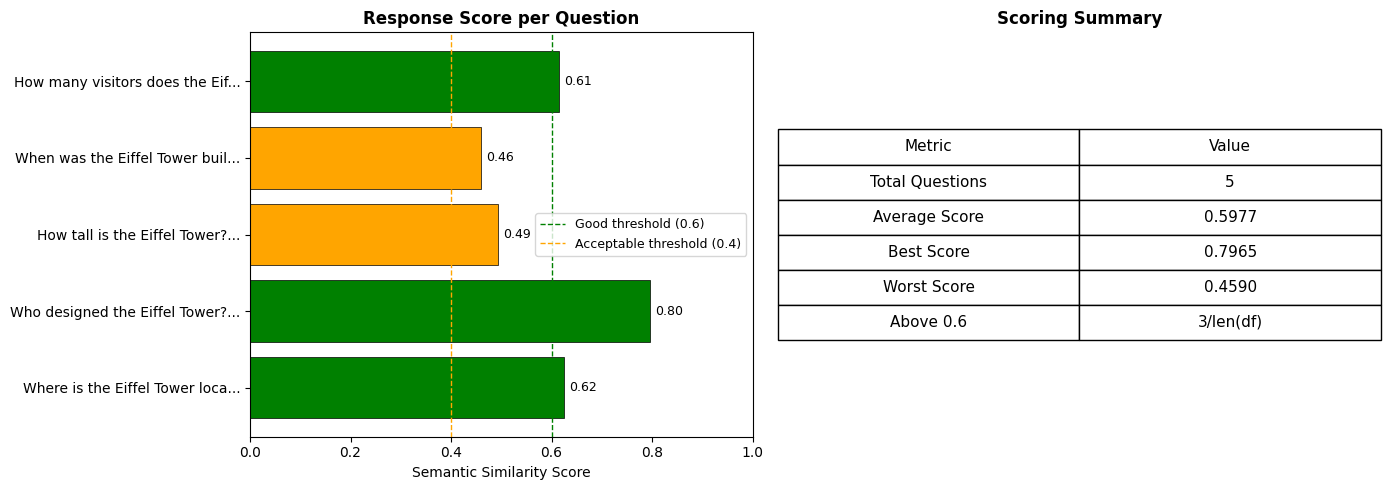

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Chart 1 - Score per question
short_questions = [q[:30] + "..." for q in df["question"]]
colors = ["green" if s > 0.6 else "orange" if s > 0.4 else "red" for s in df["score"]]

bars = axes[0].barh(short_questions, df["score"], color=colors, edgecolor="black", linewidth=0.5)
axes[0].axvline(0.6, color="green", linestyle="--", linewidth=1, label="Good threshold (0.6)")
axes[0].axvline(0.4, color="orange", linestyle="--", linewidth=1, label="Acceptable threshold (0.4)")
axes[0].set_title("Response Score per Question", fontsize=12, fontweight="bold")
axes[0].set_xlabel("Semantic Similarity Score")
axes[0].set_xlim(0, 1)
axes[0].legend(fontsize=9)

for bar, score in zip(bars, df["score"]):
    axes[0].text(score + 0.01, bar.get_y() + bar.get_height()/2,
                f"{score:.2f}", va="center", fontsize=9)

# Chart 2 - Summary
axes[1].axis("off")
summary = [
    ["Total Questions", str(len(df))],
    ["Average Score", f"{df["score"].mean():.4f}"],
    ["Best Score", f"{df["score"].max():.4f}"],
    ["Worst Score", f"{df["score"].min():.4f}"],
    ["Above 0.6", f"{(df["score"] > 0.6).sum()}/len(df)"],
]
table = axes[1].table(
    cellText=summary,
    colLabels=["Metric", "Value"],
    cellLoc="center",
    loc="center"
)
table.auto_set_font_size(False)
table.set_fontsize(11)
table.scale(1.2, 2)
axes[1].set_title("Scoring Summary", fontsize=12, fontweight="bold")
plt.tight_layout()
plt.savefig("response_scoring.png", dpi=300)
plt.show()

## 4. Key Observations

| Question | Score | Quality |
|----------|-------|---------|
| Who designed the Eiffel Tower? | 0.80 | Good |
| Where is it located? | 0.62 | Good |
| How many visitors? | 0.61 | Good |
| How tall is it? | 0.49 | Acceptable |
| When was it built? | 0.46 | Acceptable |

## Why Some Scores Are Lower
- "330 meters" vs "330 meters tall including its antenna" — correct but incomplete
- "Between 1887 and 1889" vs full sentence — same meaning, lower similarity

## Key Insight
Semantic similarity scoring is not perfect — it penalizes short correct answers.
A score of 0.46 for "Between 1887 and 1889" does not mean wrong,
it means the answer is less verbose than the reference.

## Limitation
This scoring method needs human-calibrated thresholds.
0.6 as "good" is a starting point, not a ground truth.

## Next
How do different models compare on the same tasks?
-> 04_model_comparison.ipynb